In [35]:
!pip install yfinance prophet pandas numpy matplotlib scikit-learn pymongo sentiment

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **1. Importing Packages and Libraries**

In [36]:
# Importing all the necessary libraries and packages

import math
import os
from typing import Dict

import pandas as pd
from prophet import Prophet
import yfinance as yf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Loading Data**

Loading stock price data for AAPL.

In [63]:
# Load price data for AAPL
def load_price_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Load historical price data for a given ticker symbol from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL').
        start_date (str): The start date for the historical data in 'YYYY-MM-DD' format.
        end_date (str): The end date for the historical data in 'YYYY-MM-DD' format.

    Returns:
        pd.DataFrame: A DataFrame containing the historical price data with columns
                      'Date', 'Close', and 'Industry'.
    """
    data = yf.download(ticker, start=start_date, end=end_date)

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data.reset_index(inplace=True)

    ticker_obj = yf.Ticker(ticker)
    industry = ticker_obj.info.get("industry", "Unknown")

    data["Industry"] = industry

    return data[["Date", "Close", "Industry"]]

def display_price_data(data: pd.DataFrame, ticker: str) -> None:
    """
    Display the historical price data using a line plot.

    Args:
        data (pd.DataFrame): A DataFrame containing the historical price data
                             with columns ['Date', 'Close'].
        ticker (str): The stock ticker symbol for labeling the plot.
    """
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="Date", y="Close", data=data)
    plt.title(f"Historical Closing Prices for {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.grid()
    plt.show()

In [64]:
# Load data
ticker = "AAPL"
start_date = "2020-03-28"
end_date = "2026-03-28"
forecast_periods = 30

price_data = load_price_data(ticker, start_date, end_date)

print(f"Loaded {len(price_data)} price records")

[*********************100%***********************]  1 of 1 completed


Loaded 1507 price records


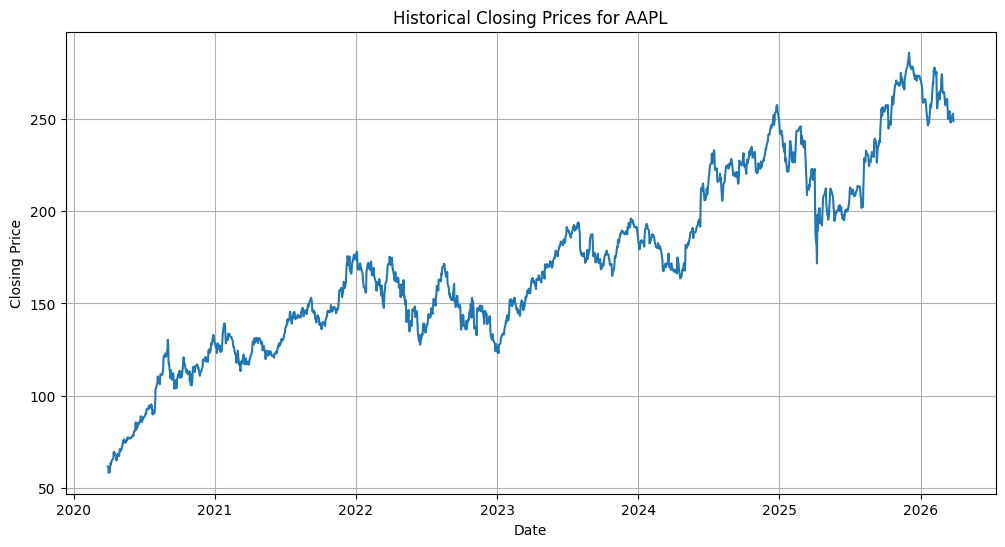

In [65]:
# Display price data
display_price_data(price_data, ticker)

### **3. Forecasting**

Forecast future stock prices using the Prophet model.

In [66]:
def forecast_prices(data: pd.DataFrame, periods: int) -> pd.DataFrame:
    """
    Forecast future stock prices using the Prophet model.

    Args:
        data (pd.DataFrame): A DataFrame containing the historical price data
                             with columns ['Date', 'Close', 'Industry'].
        periods (int): The number of future periods (days) to forecast.

    Returns:
        pd.DataFrame: A DataFrame containing the forecasted prices with columns
                      ['ds', 'yhat', 'yhat_lower', 'yhat_upper'].
    """
    df = data.rename(columns={"Date": "ds", "Close": "y", "Industry": "industry"})
    df = df.dropna(subset=["ds", "y"]).copy()

    if df.empty:
        raise ValueError("No historical price data available for forecasting.")

    model = Prophet()
    model.fit(df[["ds", "y"]])

    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    return forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

In [67]:
forecasted_prices = forecast_prices(price_data, forecast_periods)

21:58:54 - cmdstanpy - INFO - Chain [1] start processing
21:58:55 - cmdstanpy - INFO - Chain [1] done processing


### **4. Metrics Function**

In [68]:
def evaluate_forecast(data: pd.DataFrame, forecast: pd.DataFrame) -> Dict[str, float]:
    """
    Evaluate the forecasted prices against actual historical prices using MAE and RMSE.

    Args:
        data (pd.DataFrame): A DataFrame containing the historical price data
                             with columns ['Date', 'Close'].
        forecast (pd.DataFrame): A DataFrame containing the forecasted prices
                                 with columns ['ds', 'yhat'].

    Returns:
        Dict[str, float]: A dictionary containing the MAE, RMSE, and R² values.
    """
    merged = pd.merge(data, forecast, left_on="Date", right_on="ds", how="inner")

    if merged.empty:
        return {"MAE": 0.0, "RMSE": 0.0, "R2": 0.0}
    
    mae = mean_absolute_error(merged["Close"], merged["yhat"])
    rmse = math.sqrt(mean_squared_error(merged["Close"], merged["yhat"]))
    r2 = 1 - (
        sum((merged["Close"] - merged["yhat"]) ** 2)
        / sum((merged["Close"] - merged["Close"].mean()) ** 2)
    )

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

### **5. Visualizing Forecasting Results**

In [69]:
def plot_forecast(data: pd.DataFrame, forecast: pd.DataFrame, ticker: str, save_dir: str = None) -> None:
    """
    Plot historical data, model fit, and future forecast.

    If save_dir is provided, saves the plot as a PNG in subfolders:
    'historical', 'future', and 'yearly' under save_dir.
    """
    plt.figure(figsize=(12, 6))

    last_date = data["Date"].max()

    forecast_history = forecast[forecast["ds"] <= last_date]
    forecast_future = forecast[forecast["ds"] > last_date]

    plt.plot(data["Date"], data["Close"], label="Historical Data", color="black")

    plt.plot(
        forecast_history["ds"],
        forecast_history["yhat"],
        label="Model Fit",
        linestyle="--",
        color="blue",
    )

    plt.plot(
        forecast_future["ds"],
        forecast_future["yhat"],
        label="Forecast (Future)",
        linestyle="--",
        color="red",
    )

    plt.fill_between(
        forecast["ds"],
        forecast["yhat_lower"],
        forecast["yhat_upper"],
        color="gray",
        alpha=0.2,
    )

    plt.axvline(x=last_date, color="gray", linestyle="-", label="Forecast Start")

    plt.title(f"{ticker} Stock Price Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_dir:
        for subdir in ["historical", "future", "yearly"]:
            out_dir = os.path.join(save_dir, subdir)
            os.makedirs(out_dir, exist_ok=True)
            save_path = os.path.join(out_dir, f"{ticker}_forecast.png")
            plt.savefig(save_path)
            print(f"Saved forecast plot: {save_path}")

    # plt.show()
    plt.close()

### **6. Evaluation**

Evaluate the forecasting model performance.

In [70]:
def plot_yearly_forecasts(data: pd.DataFrame, forecast: pd.DataFrame, ticker: str, save_dir: str = "plots") -> None:
    """
    Create yearly forecast plots for each year in the dataset.
    Saves each year's plot to plots/yearly/ticker_year.png
    
    Args:
        data (pd.DataFrame): Historical price data with 'Date' and 'Close' columns.
        forecast (pd.DataFrame): Forecast data with 'ds', 'yhat', 'yhat_lower', 'yhat_upper'.
        ticker (str): Stock ticker symbol.
        save_dir (str): Base directory for saving plots.
    """
    if data.empty or forecast.empty:
        print(f"Skipping yearly plots for {ticker}: empty data")
        return
    
    # Convert to datetime if needed
    if not pd.api.types.is_datetime64_any_dtype(data['Date']):
        data = data.copy()
        data['Date'] = pd.to_datetime(data['Date'])
    
    if not pd.api.types.is_datetime64_any_dtype(forecast['ds']):
        forecast = forecast.copy()
        forecast['ds'] = pd.to_datetime(forecast['ds'])
    
    # Extract unique years from the data
    years = sorted(data['Date'].dt.year.unique())
    
    # Create plots/yearly directory
    yearly_dir = os.path.join(save_dir, "yearly")
    os.makedirs(yearly_dir, exist_ok=True)
    
    for year in years:
        plt.figure(figsize=(12, 6))
        
        # Filter data for the current year
        year_start = pd.Timestamp(f"{year}-01-01")
        year_end = pd.Timestamp(f"{year}-12-31")
        
        year_data = data[(data['Date'] >= year_start) & (data['Date'] <= year_end)]
        year_forecast = forecast[(forecast['ds'] >= year_start) & (forecast['ds'] <= year_end)]
        
        # Plot actual data in black (like historical data in main plot)
        if not year_data.empty:
            plt.plot(year_data['Date'], year_data['Close'], 
                    label='Historical Data', color='black')
        
        # Separate forecast into history and future for this year
        year_end_date = year_data['Date'].max() if not year_data.empty else year_end
        
        forecast_history = year_forecast[year_forecast['ds'] <= year_end_date]
        forecast_future = year_forecast[year_forecast['ds'] > year_end_date]
        
        # Plot model fit (past forecast) in blue dashed
        if not forecast_history.empty:
            plt.plot(forecast_history['ds'], forecast_history['yhat'],
                    label='Model Fit', linestyle='--', color='blue')
        
        # Plot future forecast in red dashed
        if not forecast_future.empty:
            plt.plot(forecast_future['ds'], forecast_future['yhat'],
                    label='Forecast (Future)', linestyle='--', color='red')
        
        # Add confidence interval for all forecast data
        if not year_forecast.empty:
            plt.fill_between(year_forecast['ds'], 
                            year_forecast['yhat_lower'], 
                            year_forecast['yhat_upper'],
                            color='gray', alpha=0.2)
        
        # Add vertical line at year end if there's a forecast boundary
        if not year_data.empty:
            plt.axvline(x=year_end_date, color='gray', linestyle='-')
        
        plt.title(f"{ticker} Stock Price Forecast - {year}")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        
        # Save the plot
        save_path = os.path.join(yearly_dir, f"{ticker}_{year}.png")
        plt.savefig(save_path)
        print(f"Saved yearly plot: {save_path}")
        
        plt.close()

In [71]:
def run_forecast_for_tickers(tickers, start_date, end_date, forecast_periods):
    """Run forecast and evaluation for a list of tickers."""
    plot_base = "plots"

    results = []

    for ticker in tickers:
        try:
            print(f"Processing {ticker}...")

            price_data = load_price_data(ticker, start_date, end_date)
            forecast_data = forecast_prices(price_data, forecast_periods)

            eval_metrics = evaluate_forecast(price_data, forecast_data)

            results.append({
                "ticker": ticker,
                "MAE": eval_metrics["MAE"],
                "RMSE": eval_metrics["RMSE"],
                "R2": eval_metrics["R2"],
            })

            plot_forecast(price_data, forecast_data, ticker, save_dir=plot_base)
            plot_yearly_forecasts(price_data, forecast_data, ticker, save_dir=plot_base)

        except Exception as exc:
            print(f"Failed for {ticker}: {exc}")

    results_df = pd.DataFrame(results)
    results_df.to_csv("evaluation_results.csv", index=False)
    print("Saved evaluation results to evaluation_results.csv")

    return results_df

In [72]:
# Consolidated evaluation for all tickers

tickers = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOG", "META", "TSLA", "BRK-B", "JPM", "JNJ",
    "V", "UNH", "PG", "MA", "DIS", "HD", "PFE", "BAC", "NFLX", "ORCL",
    "CMCSA", "XOM", "CVX", "UNP", "KO"
]

final_results_df = run_forecast_for_tickers(tickers, start_date, end_date, forecast_periods)
print(final_results_df)

[*********************100%***********************]  1 of 1 completed

Processing AAPL...



21:58:59 - cmdstanpy - INFO - Chain [1] start processing
21:59:00 - cmdstanpy - INFO - Chain [1] done processing


Saved forecast plot: plots\historical\AAPL_forecast.png
Saved forecast plot: plots\future\AAPL_forecast.png
Saved forecast plot: plots\yearly\AAPL_forecast.png
Saved yearly plot: plots\yearly\AAPL_2020.png
Saved yearly plot: plots\yearly\AAPL_2021.png
Saved yearly plot: plots\yearly\AAPL_2022.png
Saved yearly plot: plots\yearly\AAPL_2023.png
Saved yearly plot: plots\yearly\AAPL_2024.png
Saved yearly plot: plots\yearly\AAPL_2025.png
Saved yearly plot: plots\yearly\AAPL_2026.png
Processing MSFT...


[*********************100%***********************]  1 of 1 completed
21:59:07 - cmdstanpy - INFO - Chain [1] start processing
21:59:08 - cmdstanpy - INFO - Chain [1] done processing


...

Saved forecast plot: plots\historical\CVX_forecast.png
Saved forecast plot: plots\future\CVX_forecast.png
Saved forecast plot: plots\yearly\CVX_forecast.png
Saved yearly plot: plots\yearly\CVX_2020.png
Saved yearly plot: plots\yearly\CVX_2021.png
Saved yearly plot: plots\yearly\CVX_2022.png
Saved yearly plot: plots\yearly\CVX_2023.png
Saved yearly plot: plots\yearly\CVX_2024.png
Saved yearly plot: plots\yearly\CVX_2025.png
Saved yearly plot: plots\yearly\CVX_2026.png
Processing UNP...


[*********************100%***********************]  1 of 1 completed
22:01:57 - cmdstanpy - INFO - Chain [1] start processing
22:01:58 - cmdstanpy - INFO - Chain [1] done processing


Saved forecast plot: plots\historical\UNP_forecast.png
Saved forecast plot: plots\future\UNP_forecast.png
Saved forecast plot: plots\yearly\UNP_forecast.png
Saved yearly plot: plots\yearly\UNP_2020.png
Saved yearly plot: plots\yearly\UNP_2021.png
Saved yearly plot: plots\yearly\UNP_2022.png
Saved yearly plot: plots\yearly\UNP_2023.png
Saved yearly plot: plots\yearly\UNP_2024.png
Saved yearly plot: plots\yearly\UNP_2025.png
Saved yearly plot: plots\yearly\UNP_2026.png
Processing KO...


[*********************100%***********************]  1 of 1 completed
22:02:06 - cmdstanpy - INFO - Chain [1] start processing
22:02:07 - cmdstanpy - INFO - Chain [1] done processing


Saved forecast plot: plots\historical\KO_forecast.png
Saved forecast plot: plots\future\KO_forecast.png
Saved forecast plot: plots\yearly\KO_forecast.png
Saved yearly plot: plots\yearly\KO_2020.png
Saved yearly plot: plots\yearly\KO_2021.png
Saved yearly plot: plots\yearly\KO_2022.png
Saved yearly plot: plots\yearly\KO_2023.png
Saved yearly plot: plots\yearly\KO_2024.png
Saved yearly plot: plots\yearly\KO_2025.png
Saved yearly plot: plots\yearly\KO_2026.png
Saved evaluation results to evaluation_results.csv
   ticker        MAE       RMSE        R2
0    AAPL   7.665449   9.798792  0.960376
1    MSFT  15.989633  21.286269  0.952501
2    NVDA   5.444484   7.512765  0.984671
3    AMZN   8.005367  10.397403  0.931731
4    GOOG   8.511876  11.290811  0.963819
5    META  22.041901  29.845211  0.973994
6    TSLA  28.355132  36.644149  0.850218
7   BRK-B   8.993830  11.253561  0.987159
8     JPM   5.579712   7.479025  0.988106
9     JNJ   3.843740   4.946194  0.950125
10      V   6.593797   8.

In [56]:
# Plotting is handled inside run_forecast_for_tickers per ticker.